In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import root_mean_squared_error
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from tqdm import tqdm

In [5]:
os.chdir("C:/Python/Datasets")
df = pd.read_csv("Electric_Production.csv")
y = df['IPG2211A2N']
y_train = y.iloc[:-13]
y_test = y.iloc[-13:]

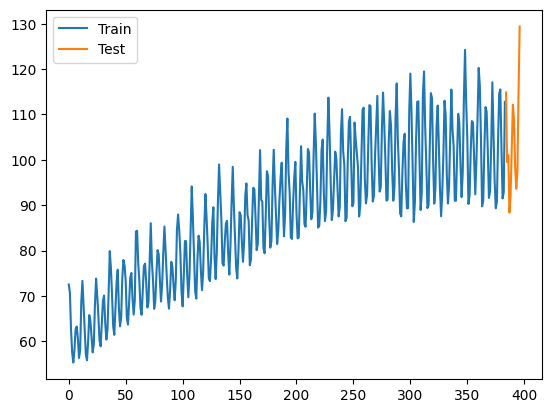

In [7]:
plt.plot(y_train, label='Train')
plt.plot(y_test, label='Test')
plt.legend()
plt.show()

In [41]:
alphas = np.linspace(0.01, 0.9, 10)
betas = np.linspace(0.01, 0.9, 10)
gammas = np.linspace(0.01, 0.9, 10)
scores = []

for i in tqdm(range(len(alphas))):
    for b in betas:
        for g in gammas:
            hw_add = ExponentialSmoothing(y_train, seasonal_periods=12,  
                                          trend='add', seasonal='add')
            fit1 = hw_add.fit(smoothing_level=alphas[i], 
                              smoothing_trend=b, smoothing_seasonal=g)
            y_pred = fit1.forecast(len(y_test))
            scores.append([alphas[i], b,g,root_mean_squared_error(y_test, y_pred) ])


 10%|████████▎                                                                          | 1/10 [00:02<00:23,  2.61s/it]C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
 20%|████████████████▌                                                                  | 2/10 [00:05<00:22,  2.84s/it]C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: Conver

In [42]:
df_scores = pd.DataFrame(scores, columns=['alpha', 'beta','gamma','score'])
df_scores.sort_values('score').iloc[0]

alpha    0.603333
beta     0.702222
gamma    0.010000
score    4.300439
Name: 670, dtype: float64

In [45]:
alphas = np.linspace(0.01, 0.9, 10)
betas = np.linspace(0.01, 0.9, 10)
gammas = np.linspace(0.01, 0.9, 10)
scores = []

for i in tqdm(range(len(alphas))):
    for b in betas:
        for g in gammas:
            hw_add = ExponentialSmoothing(y_train, seasonal_periods=12,  
                                          trend='add', seasonal='mul')
            fit1 = hw_add.fit(smoothing_level=alphas[i], 
                              smoothing_trend=b, smoothing_seasonal=g)
            y_pred = fit1.forecast(len(y_test))
            scores.append([alphas[i], b,g,root_mean_squared_error(y_test, y_pred) ])


 10%|████████▎                                                                          | 1/10 [00:04<00:36,  4.05s/it]C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Python\anaconda3\Lib\site-package

In [47]:
df_scores = pd.DataFrame(scores, columns=['alpha', 'beta','gamma','score'])
df_scores.sort_values('score').iloc[0]

alpha    0.603333
beta     0.801111
gamma    0.010000
score    4.186795
Name: 680, dtype: float64

In [55]:
alphas = np.linspace(0.01, 0.9, 10)
betas = np.linspace(0.01, 0.9, 10)
gammas = np.linspace(0.01, 0.9, 10)
phis = np.linspace(0.01, 0.9, 10)
scores = []

for i in tqdm(range(len(alphas))):
    for b in betas:
        for g in gammas:
            for p in phis:
                hw_add = ExponentialSmoothing(y_train, seasonal_periods=12,  
                                              trend='add', seasonal='add', damped_trend=True)
                fit1 = hw_add.fit(smoothing_level=alphas[i], 
                                  smoothing_trend=b, smoothing_seasonal=g, damping_trend=p)
                y_pred = fit1.forecast(len(y_test))
                scores.append([alphas[i], b,g,p,root_mean_squared_error(y_test, y_pred) ])


 20%|████████████████▌                                                                  | 2/10 [00:45<02:56, 22.12s/it]C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
 30%|████████████████████████▉                                                          | 3/10 [01:05<02:29, 21.38s/it]C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
 40%|█████████████████████████████████▏                                                 | 4/10 [01:26<02:06, 21.12s/it]C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Che

In [56]:
df_scores = pd.DataFrame(scores, columns=['alpha', 'beta','phi','gamma','score'])
df_scores.sort_values('score').iloc[0]

alpha    0.504444
beta     0.801111
phi      0.702222
gamma    0.702222
score    4.299877
Name: 5877, dtype: float64

In [61]:
alphas = np.linspace(0.01, 0.9, 10)
betas = np.linspace(0.01, 0.9, 10)
gammas = np.linspace(0.01, 0.9, 10)
phis = np.linspace(0.01, 0.9, 10)
scores = []

for i in tqdm(range(len(alphas))):
    for b in betas:
        for g in gammas:
            for p in phis:
                hw_add = ExponentialSmoothing(y_train, seasonal_periods=12,  
                                              trend='add', seasonal='mul', damped_trend=True)
                fit1 = hw_add.fit(smoothing_level=alphas[i], 
                                  smoothing_trend=b, smoothing_seasonal=g, damping_trend=p)
                y_pred = fit1.forecast(len(y_test))
                scores.append([alphas[i], b,g,p,root_mean_squared_error(y_test, y_pred) ])


 10%|████████▎                                                                          | 1/10 [00:32<04:53, 32.60s/it]C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
 20%|████████████████▌                                                                  | 2/10 [01:01<04:03, 30.38s/it]C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Python\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: Conver

In [62]:
df_scores = pd.DataFrame(scores, columns=['alpha', 'beta','phi','gamma','score'])
df_scores.sort_values('score').iloc[0]

alpha    0.504444
beta     0.801111
phi      0.702222
gamma    0.702222
score    4.118010
Name: 5877, dtype: float64

#### Default (auto-tuning)

In [66]:
hw_add = ExponentialSmoothing(y_train, seasonal_periods=12,  
                              trend='add', seasonal='add')
fit1 = hw_add.fit()
y_pred = fit1.forecast(len(y_test))
root_mean_squared_error(y_test, y_pred)

5.16777001604037

In [68]:
fit1.params

{'smoothing_level': 0.5220588477907347,
 'smoothing_trend': 6.8936448895086215e-09,
 'smoothing_seasonal': 0.24699062367205846,
 'damping_trend': nan,
 'initial_level': 62.442022290330655,
 'initial_trend': 0.10996436912500115,
 'initial_seasons': array([10.31665895,  6.51601399,  0.44894063, -5.25574543, -6.51316168,
        -2.33540841,  2.40600939,  2.11339142, -2.58873804, -6.22216784,
        -3.95345297,  5.61500771]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [71]:
hw_add = ExponentialSmoothing(y_train, seasonal_periods=12,  
                              trend='add', seasonal='mul')
fit1 = hw_add.fit()
y_pred = fit1.forecast(len(y_test))
root_mean_squared_error(y_test, y_pred)

5.272939249057943

In [75]:
hw_add = ExponentialSmoothing(y_train, seasonal_periods=12,  
                              trend='add', seasonal='add', damped_trend=True)
fit1 = hw_add.fit()
y_pred = fit1.forecast(len(y_test))
root_mean_squared_error(y_test, y_pred)

5.0894288993901675

In [77]:
hw_add = ExponentialSmoothing(y_train, seasonal_periods=12,  
                              trend='add', seasonal='mul', damped_trend=True)
fit1 = hw_add.fit()
y_pred = fit1.forecast(len(y_test))
root_mean_squared_error(y_test, y_pred)

5.184334672947812